In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/Crop_recommendation.csv
/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/price_dataset.csv


In [51]:
import os
import time
import random
import warnings
import joblib
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [3]:
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")

PROJECT_DIR = "/content/AGRISENSE"

FIGURE_DIR = os.path.join(PROJECT_DIR, "Figures")
MODEL_DIR = os.path.join(PROJECT_DIR, "Saved_Models")
RESULT_DIR = os.path.join(PROJECT_DIR, "Results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Project folders created successfully.")

try:
    import torch

    if torch.cuda.is_available():
        print("=" * 60)
        print("GPU Available")
        print("=" * 60)
        print("GPU Name :", torch.cuda.get_device_name(0))
    else:
        print("=" * 60)
        print("GPU Not Available")
        print("Using CPU")
except ImportError:
    print("=" * 60)
    print("PyTorch not installed. GPU check skipped.")
    print("=" * 60)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\nCross Validation Strategy")
print(cv)

print("\nProject Structure")
print("-" * 40)

print(PROJECT_DIR)
print("│")
print("├── Figures")
print("├── Results")
print("└── Saved_Models")

print("\nEnvironment setup completed successfully.")
print("=" * 60)

Project folders created successfully.
GPU Not Available
Using CPU

Cross Validation Strategy
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

Project Structure
----------------------------------------
/content/AGRISENSE
│
├── Figures
├── Results
└── Saved_Models

Environment setup completed successfully.


In [4]:
DATASET_PATH = "/kaggle/input/datasets/adityapatekar/crop-and-price-datatset/Datasets/Crop_recommendation.csv"

crop_df = pd.read_csv(DATASET_PATH)

print("\nDataset loaded successfully.")

print("\nDataset Shape")
print("-" * 40)
print(f"Rows    : {crop_df.shape[0]}")
print(f"Columns : {crop_df.shape[1]}")

print("\nColumn Names")
print("-" * 40)

for column in crop_df.columns:
    print(column)


Dataset loaded successfully.

Dataset Shape
----------------------------------------
Rows    : 18079
Columns : 8

Column Names
----------------------------------------
Unnamed: 0
Crop
N
P
K
pH
rainfall
temperature


In [5]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18079 entries, 0 to 18078
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   18079 non-null  int64  
 1   Crop         18079 non-null  object 
 2   N            18079 non-null  int64  
 3   P            18079 non-null  int64  
 4   K            18079 non-null  int64  
 5   pH           18079 non-null  float64
 6   rainfall     18079 non-null  float64
 7   temperature  18079 non-null  float64
dtypes: float64(3), int64(4), object(1)
memory usage: 1.1+ MB


In [6]:
display(crop_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,18079.0,49799.491565,28625.445698,8.000000,25037.000000,49799.000000,74418.000000,99842.000000
N,18079.0,72.683500,40.019864,10.000000,50.000000,80.000000,80.000000,180.000000
P,18079.0,43.489408,14.051089,10.000000,40.000000,40.000000,60.000000,125.000000
K,18079.0,41.607666,27.584765,10.000000,20.000000,30.000000,50.000000,200.000000
pH,18079.0,5.581247,0.477354,3.820000,5.340000,5.500000,5.680000,7.000000
rainfall,18079.0,661.896078,578.161909,3.274569,127.680000,579.750000,1037.320000,3322.060000
temperature,18079.0,26.496760,4.970138,1.180000,22.890909,26.736364,29.186364,35.346667


In [7]:
missing = crop_df.isnull().sum()
print("\nMissing Values Stats:\n",missing)

duplicates = crop_df.duplicated().sum()
print("\nDuplicates Found:",duplicates)


Missing Values Stats:
 Unnamed: 0     0
Crop           0
N              0
P              0
K              0
pH             0
rainfall       0
temperature    0
dtype: int64

Duplicates Found: 0


In [8]:
print("\nTarget Variable")
print("-" * 40)

target = "Crop"

print(f"Target Column : {target}")

print(f"\nTotal Crop Classes : {crop_df[target].nunique()}")


Target Variable
----------------------------------------
Target Column : Crop

Total Crop Classes : 40


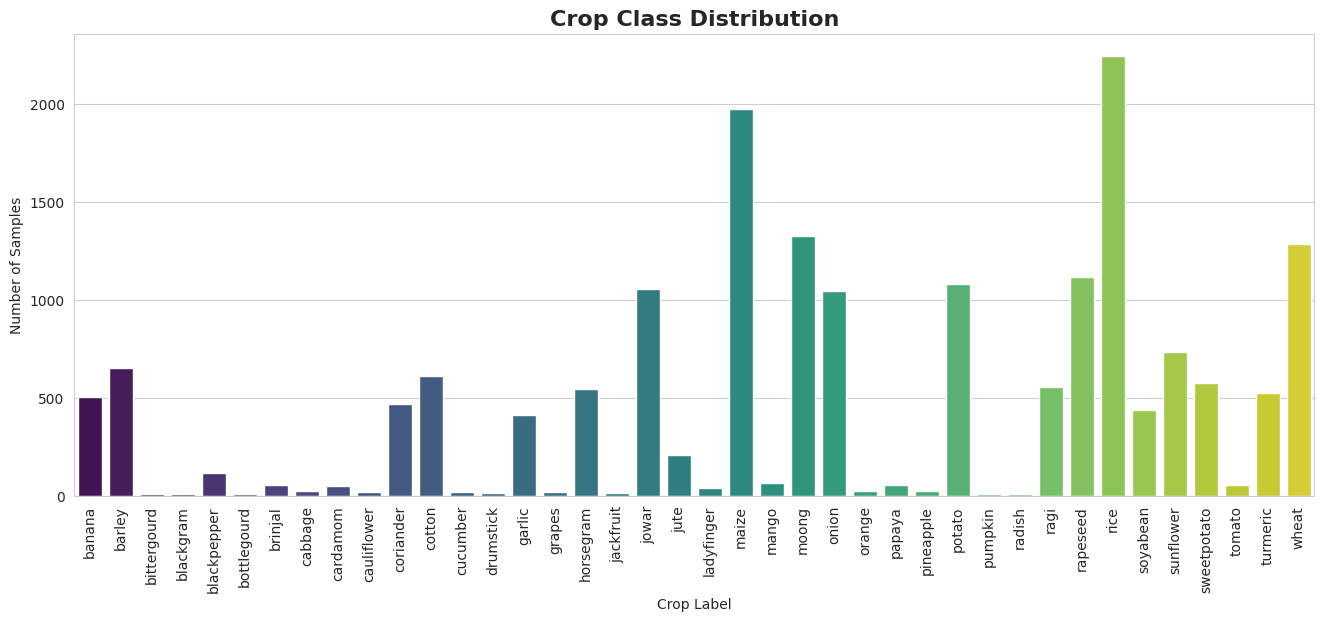

In [9]:
plt.figure(figsize=(16,6))

sns.countplot(
    data=crop_df,
    x=target,
    order=sorted(crop_df[target].unique()),
    palette="viridis"
)

plt.title(
    "Crop Class Distribution",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Crop Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.savefig("Figure_01_Crop_Class_Distribution.png")

plt.show()

In [10]:
# ============================================================
# Dataset Balance Check
# ============================================================

print("\nDataset Balance Statistics")
print("-" * 40)

class_distribution = crop_df[target].value_counts().sort_index()

if class_distribution.std() == 0:
    print("\nDataset is perfectly balanced.")
else:
    print("\nDataset is imbalanced.")


Dataset Balance Statistics
----------------------------------------

Dataset is imbalanced.


In [11]:
FEATURES = [
    "N",
    "P",
    "K",
    "temperature",
    "ph",
    "rainfall"
]

TARGET = "Crop"

print("\nInput Features")
print("-" * 40)

for feature in FEATURES:
    print(feature)

print(f"\nTarget : {TARGET}")


Input Features
----------------------------------------
N
P
K
temperature
ph
rainfall

Target : Crop


In [12]:
missing_features = [f for f in FEATURES if f not in crop_df.columns]
print(missing_features)

['ph']


In [13]:
crop_df.rename(columns={
    "Humidity": "humidity",
    "pH": "ph"
}, inplace=True)

In [14]:
print(crop_df.columns.tolist())

['Unnamed: 0', 'Crop', 'N', 'P', 'K', 'ph', 'rainfall', 'temperature']


In [15]:
# ============================================================
# Check Dataset Integrity
# ============================================================

assert TARGET in crop_df.columns

for feature in FEATURES:
    assert feature in crop_df.columns

print("\nDataset Integrity Check Passed.")


Dataset Integrity Check Passed.


In [16]:
# ============================================================
# Section Summary
# ============================================================

print("\n" + "=" * 80)
print("SECTION 2 COMPLETED SUCCESSFULLY")
print("=" * 80)

print(f"""
Summary
-------
Total Samples           : {crop_df.shape[0]}
Total Features          : {len(FEATURES)}
Target Classes          : {crop_df[TARGET].nunique()}
Missing Values          : {crop_df.isnull().sum().sum()}
Duplicate Records       : {duplicates}
""")


SECTION 2 COMPLETED SUCCESSFULLY

Summary
-------
Total Samples           : 18079
Total Features          : 6
Target Classes          : 40
Missing Values          : 0
Duplicate Records       : 0



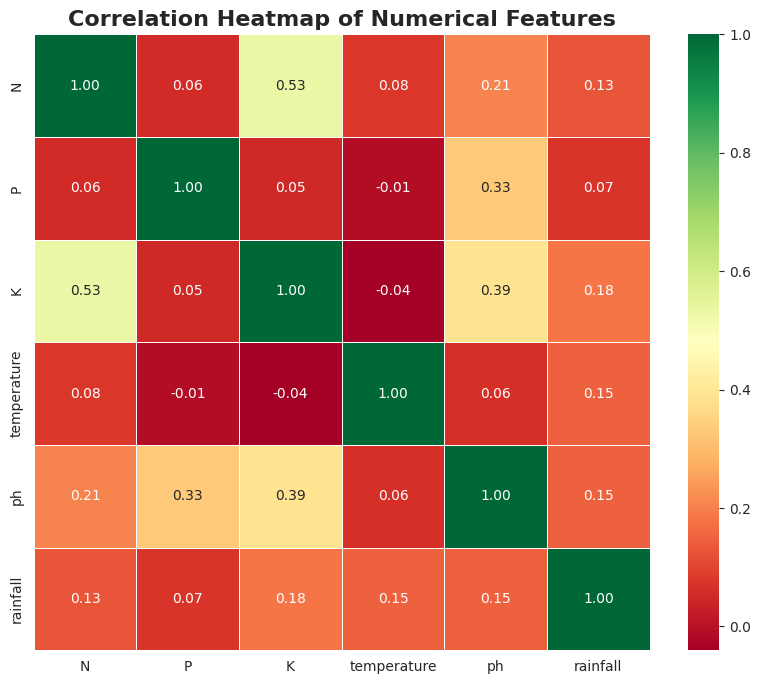

In [28]:
plt.figure(figsize=(10,8))

corr = crop_df[FEATURES].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=16,
    weight="bold"
)

plt.savefig("Correlation Heatmap of Numerical Features")

plt.show()

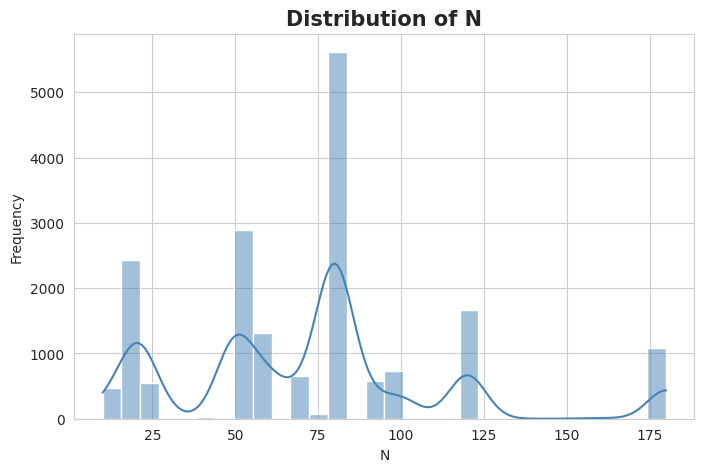

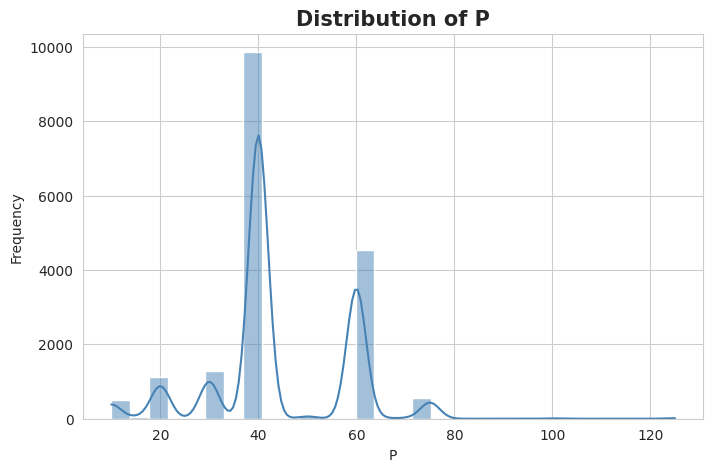

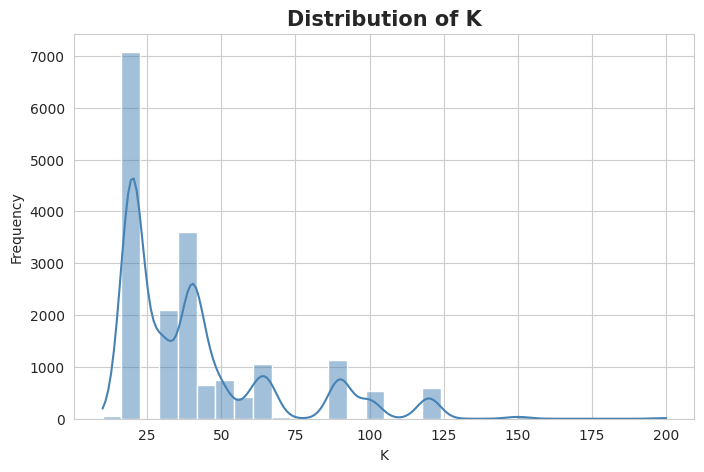

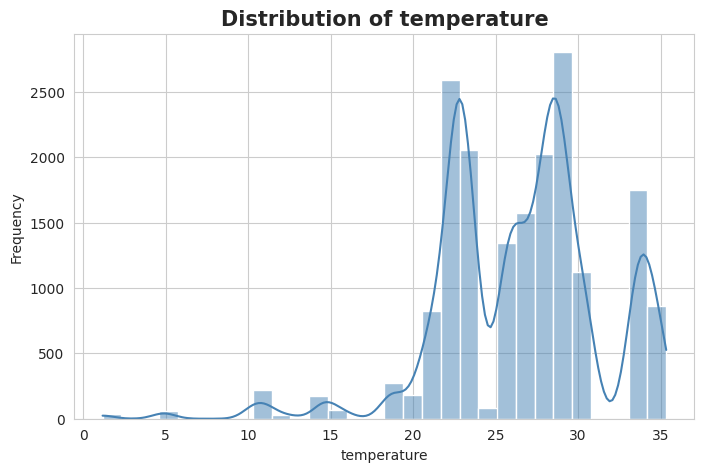

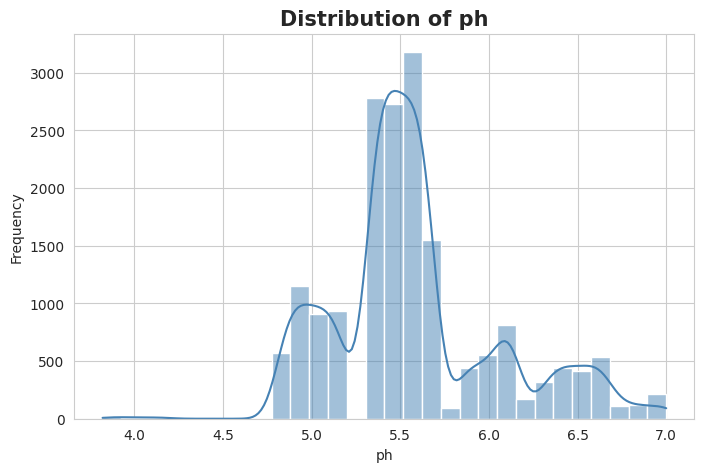

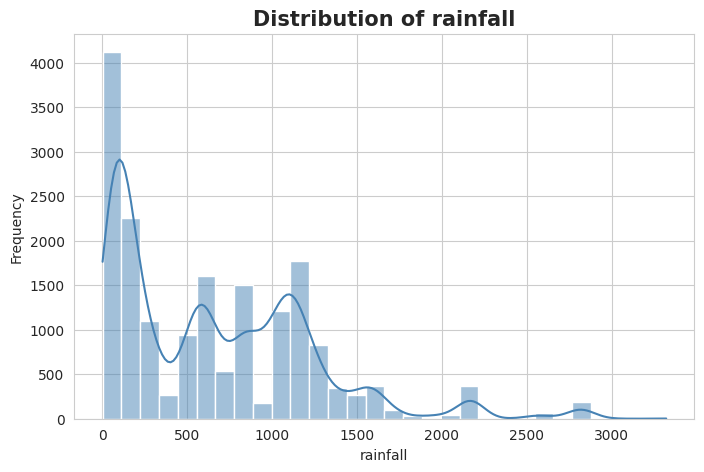

In [18]:
for feature in FEATURES:

    plt.figure(figsize=(8,5))

    sns.histplot(
        crop_df[feature],
        kde=True,
        bins=30,
        color="steelblue"
    )

    plt.title(
        f"Distribution of {feature}",
        fontsize=15,
        weight="bold"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    # plt.savefig(f"Distribution_{feature}.png")

    plt.show()

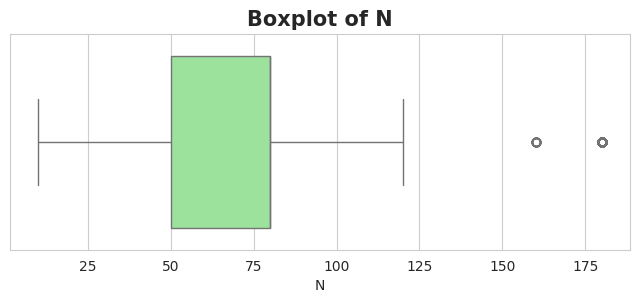

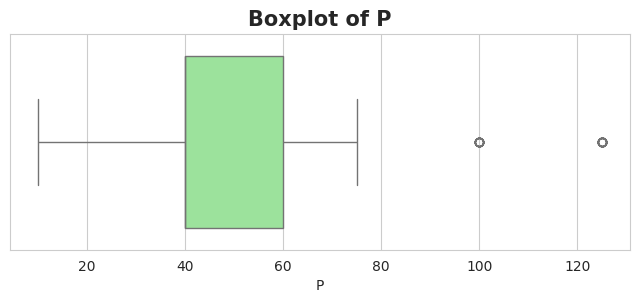

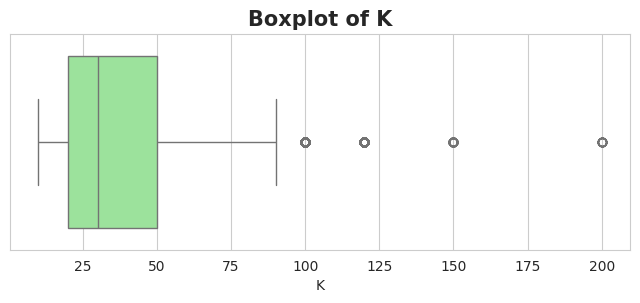

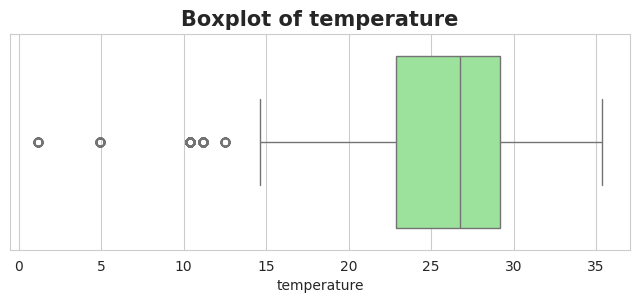

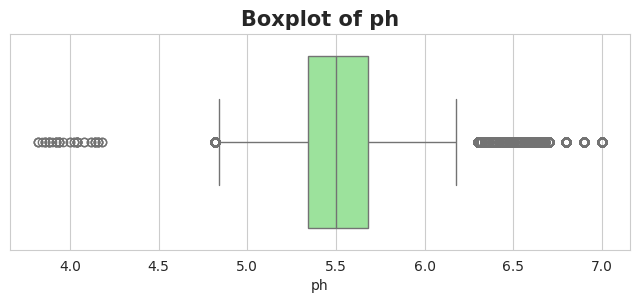

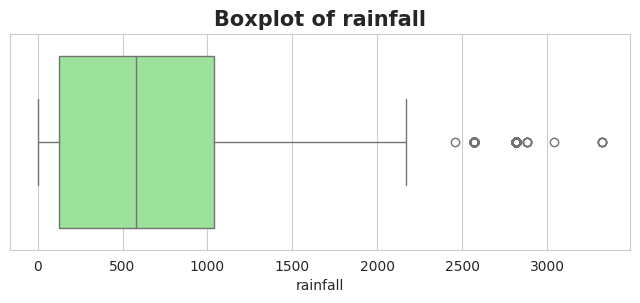

In [19]:
for feature in FEATURES:

    plt.figure(figsize=(8,2.8))

    sns.boxplot(
        x=crop_df[feature],
        color="lightgreen"
    )

    plt.title(
        f"Boxplot of {feature}",
        fontsize=15,
        weight="bold"
    )

    # plt.savefig(f"Boxplot_{feature}.png")

    plt.show()

In [20]:
FEATURES = ["N", "P", "K", "ph", "temperature", "rainfall"]

numeric_df = crop_df[FEATURES]

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

mask = ~(
    ((numeric_df < (Q1 - 1.5 * IQR)) |
     (numeric_df > (Q3 + 1.5 * IQR)))
    .any(axis=1)
)

crop_df = crop_df[mask]

print("Remaining rows:", len(crop_df))

Remaining rows: 13299


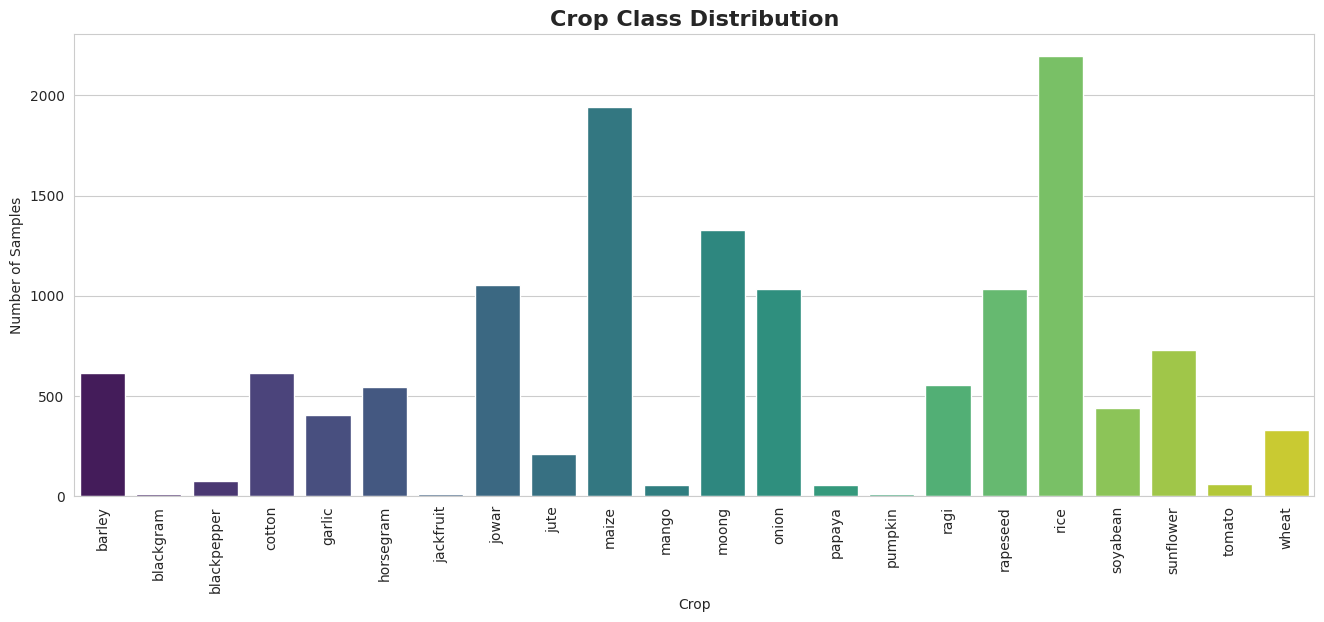

In [21]:
plt.figure(figsize=(16,6))

order = sorted(crop_df["Crop"].unique())

sns.countplot(
    data=crop_df,
    x="Crop",
    order=order,
    palette="viridis"
)

plt.xticks(rotation=90)

plt.title(
    "Crop Class Distribution",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Crop")

plt.ylabel("Number of Samples")

plt.savefig("Figure_04_Target_Distribution.png")

plt.show()

In [22]:
FEATURES = [
    "N",
    "P",
    "K",
    "temperature",
    "ph",
    "rainfall"
]

TARGET = "Crop"

X = crop_df[FEATURES]
y = crop_df[TARGET]

print("\nFeatures Selected")
print(FEATURES)

print("\nTarget Variable")
print(TARGET)


Features Selected
['N', 'P', 'K', 'temperature', 'ph', 'rainfall']

Target Variable
Crop


In [23]:
crop_df["Crop"].value_counts().index

Index(['rice', 'maize', 'moong', 'jowar', 'onion', 'rapeseed', 'sunflower',
       'cotton', 'barley', 'ragi', 'horsegram', 'soyabean', 'garlic', 'wheat',
       'jute', 'blackpepper', 'tomato', 'mango', 'papaya', 'jackfruit',
       'blackgram', 'pumpkin'],
      dtype='object', name='Crop')

In [24]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\nCrop Labels")

for index, crop in enumerate(label_encoder.classes_):
    print(f"{index} ---> {crop}")


Crop Labels
0 ---> barley
1 ---> blackgram
2 ---> blackpepper
3 ---> cotton
4 ---> garlic
5 ---> horsegram
6 ---> jackfruit
7 ---> jowar
8 ---> jute
9 ---> maize
10 ---> mango
11 ---> moong
12 ---> onion
13 ---> papaya
14 ---> pumpkin
15 ---> ragi
16 ---> rapeseed
17 ---> rice
18 ---> soyabean
19 ---> sunflower
20 ---> tomato
21 ---> wheat


In [25]:
print("\nSplitting Dataset")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)


Splitting Dataset
--------------------------------------------------

Training Samples : 10639
Testing Samples  : 2660
Training Features: (10639, 6)
Testing Features : (2660, 6)


In [26]:
print("\nEncoded Crop Classes")
print("-" * 50)

encoding_df = pd.DataFrame({

    "Encoded Value":range(len(label_encoder.classes_)),

    "Crop":label_encoder.classes_

})

display(encoding_df)


Encoded Crop Classes
--------------------------------------------------


,Encoded Value,Crop
0,0,barley
1,1,blackgram
2,2,blackpepper
3,3,cotton
4,4,garlic
5,5,horsegram
6,6,jackfruit
7,7,jowar
8,8,jute
9,9,maize


In [27]:
# ============================================================
# 12. Section Summary
# ============================================================

print("\n" + "=" * 80)
print("SECTION 4 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""

Preprocessing Completed

✔ Missing Value Check

✔ Duplicate Check

✔ Feature Selection

✔ Label Encoding

✔ Train-Test Split (80:20)

✔ StandardScaler Applied

✔ Stratified 5-Fold Cross Validation Created

Dataset is Ready for Model Training.

""")


SECTION 4 COMPLETED SUCCESSFULLY


Preprocessing Completed

✔ Missing Value Check

✔ Duplicate Check

✔ Feature Selection

✔ Label Encoding

✔ Train-Test Split (80:20)

✔ StandardScaler Applied

✔ Stratified 5-Fold Cross Validation Created

Dataset is Ready for Model Training.




In [29]:
# Random Forest

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

print("\nHyperparameter Grid")
display(rf_param_grid)


Hyperparameter Grid


{'n_estimators': [100, 200],
 'max_depth': [10, 20, None],
 'min_samples_split': [2, 5],
 'min_samples_leaf': [1, 2],
 'max_features': ['sqrt']}

In [30]:
rf_grid = GridSearchCV(

    estimator=rf,

    param_grid=rf_param_grid,

    scoring="accuracy",

    cv=cv,

    n_jobs=-1,

    verbose=1

)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [53]:
best_rf = rf_grid.best_estimator_

print("\nBest Parameters")
print("-" * 50)

print(rf_grid.best_params_)
print("\nBest Cross Validation Accuracy")
print(round(rf_grid.best_score_,4))


Best Parameters
--------------------------------------------------
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation Accuracy
0.913


In [32]:
rf_pred = best_rf.predict(X_test)

In [33]:
rf_accuracy = accuracy_score(y_test,rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("\nModel Performance")
print("-"*50)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")


Model Performance
--------------------------------------------------
Accuracy  : 0.9120
Precision : 0.9099
Recall    : 0.9120
F1 Score  : 0.9107


In [34]:
rf_cv = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCross Validation Scores")
display(rf_cv)
print("Average CV Accuracy :",round(rf_cv.mean(),4))


Cross Validation Scores


array([0.91541353, 0.91165414, 0.91071429, 0.91588346, 0.91114245])

Average CV Accuracy : 0.913


In [35]:
print("\nClassification Report")
print("-"*50)

print(classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_
))


Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

      barley       1.00      1.00      1.00       123
   blackgram       1.00      1.00      1.00         2
 blackpepper       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00       123
      garlic       1.00      1.00      1.00        81
   horsegram       1.00      1.00      1.00       109
   jackfruit       1.00      1.00      1.00         2
       jowar       0.55      0.50      0.53       211
        jute       0.40      0.33      0.36        42
       maize       1.00      1.00      1.00       388
       mango       1.00      1.00      1.00        11
       moong       1.00      1.00      1.00       265
       onion       1.00      1.00      1.00       207
      papaya       1.00      1.00      1.00        11
     pumpkin       1.00      1.00      1.00         2
        ragi       1.00      1.00      1.00       111
    rap

<Figure size 1200x1000 with 0 Axes>

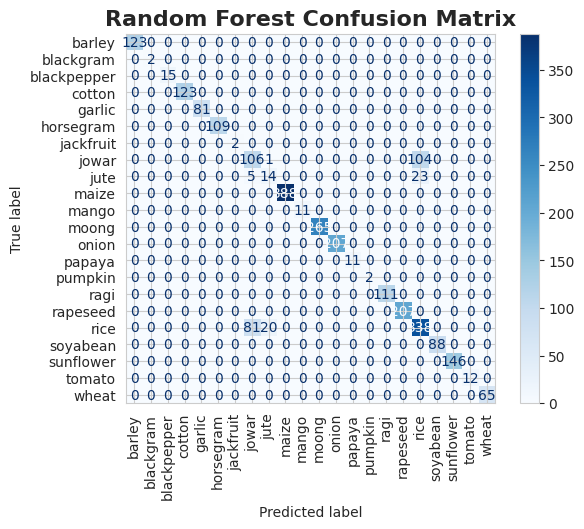

In [36]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=16,
    weight="bold"
)

plt.show()

,Feature,Importance
0,N,0.339170
2,K,0.245967
4,ph,0.176587
1,P,0.138908
5,rainfall,0.058331
3,temperature,0.041037


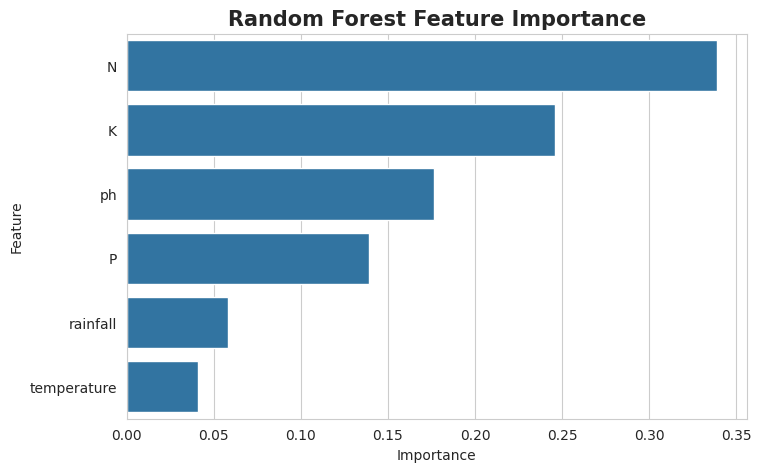

In [37]:
importance = pd.DataFrame({
    "Feature":FEATURES,
    "Importance":best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=15,
    weight="bold"
)

plt.show()

In [54]:
with open('RandomForestClassifier.pkl', 'wb') as file:
    pickle.dump(rf_pred, file)

In [38]:
# ============================================================
# Save Model
# ============================================================

joblib.dump(
    best_rf,
    os.path.join(
        MODEL_DIR,
        "RandomForest_Crop_Model.pkl"
    )
)

print("\nRandom Forest Model Saved Successfully.")

rf_results = {
    "Model":"Random Forest",
    "Accuracy":rf_accuracy,
    "Precision":rf_precision,
    "Recall":rf_recall,
    "F1 Score":rf_f1,
    "CV Accuracy":rf_cv.mean()
}

print("\nRandom Forest Results")
display(pd.DataFrame([rf_results]))

print("\n"+"="*80)
print("SECTION 5.1 COMPLETED SUCCESSFULLY")
print("="*80)


Random Forest Model Saved Successfully.

Random Forest Results


,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy
0,Random Forest,0.91203,0.909921,0.91203,0.910733,0.912962



SECTION 5.1 COMPLETED SUCCESSFULLY


In [66]:
# ============================================================
# SECTION 5.2 : XGBOOST MODEL TRAINING
# ============================================================

print("=" * 80)
print("SECTION 5.2 : XGBOOST CLASSIFIER")
print("=" * 80)

SECTION 5.2 : XGBOOST CLASSIFIER


In [67]:
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators":[100,200],
    "max_depth":[4,6,8],
    "learning_rate":[0.01,0.1],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

print("\nHyperparameter Grid")
display(xgb_param_grid)


Hyperparameter Grid


{'n_estimators': [100, 200],
 'max_depth': [4, 6, 8],
 'learning_rate': [0.01, 0.1],
 'subsample': [0.8, 1.0],
 'colsample_bytree': [0.8, 1.0]}

In [68]:
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [69]:
best_xgb = xgb_grid.best_estimator_

print("\nBest Parameters")
print(xgb_grid.best_params_)

print("\nBest Cross Validation Accuracy")
print(round(xgb_grid.best_score_,4))


Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Best Cross Validation Accuracy
0.9184


In [70]:
best_xgb = xgb_grid.best_estimator_
print("\nBest Parameters")
print(xgb_grid.best_params_)

print("\nBest Cross Validation Accuracy")
print(round(xgb_grid.best_score_,4))


Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Best Cross Validation Accuracy
0.9184


In [71]:
xgb_pred = best_xgb.predict(X_test)
xgb_accuracy = accuracy_score(y_test,xgb_pred)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    average="weighted"
)

print("\nModel Performance")
print("-"*50)
print("Accuracy :",round(xgb_accuracy,4))
print("Precision :",round(xgb_precision,4))
print("Recall :",round(xgb_recall,4))
print("F1 Score :",round(xgb_f1,4))


Model Performance
--------------------------------------------------
Accuracy : 0.9135
Precision : 0.9124
Recall : 0.9135
F1 Score : 0.9129


In [72]:
xgb_cv = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCross Validation Scores")
display(xgb_cv)
print("Average CV Accuracy :",round(xgb_cv.mean(),4))


Cross Validation Scores


array([0.92058271, 0.91635338, 0.91212406, 0.91964286, 0.92336624])

Average CV Accuracy : 0.9184


In [73]:
print("\nClassification Report")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=label_encoder.classes_
))


Classification Report
              precision    recall  f1-score   support

      barley       1.00      1.00      1.00       123
   blackgram       1.00      1.00      1.00         2
 blackpepper       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00       123
      garlic       1.00      1.00      1.00        81
   horsegram       1.00      1.00      1.00       109
   jackfruit       1.00      1.00      1.00         2
       jowar       0.57      0.57      0.57       211
        jute       0.36      0.29      0.32        42
       maize       1.00      1.00      1.00       388
       mango       1.00      1.00      1.00        11
       moong       1.00      1.00      1.00       265
       onion       1.00      1.00      1.00       207
      papaya       1.00      1.00      1.00        11
     pumpkin       1.00      1.00      1.00         2
        ragi       1.00      1.00      1.00       111
    rapeseed       1.00      1.00      1.00       207
    

<Figure size 1200x1000 with 0 Axes>

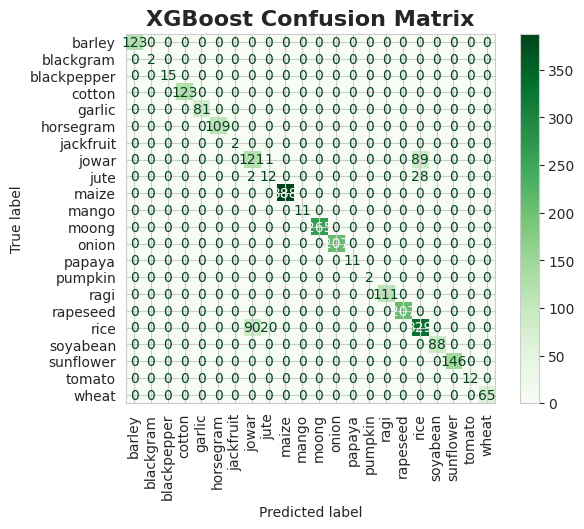

In [74]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Greens",
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "XGBoost Confusion Matrix",
    fontsize=16,
    weight="bold"
)

plt.show()

In [75]:
joblib.dump(
    best_xgb,
    os.path.join(
        MODEL_DIR,
        "XGBoost_Crop_Model.pkl"
    )
)

print("\nXGBoost Model Saved Successfully.")
xgb_results = {
    "Model":"XGBoost",
    "Accuracy":xgb_accuracy,
    "Precision":xgb_precision,
    "Recall":xgb_recall,
    "F1 Score":xgb_f1,
    "CV Accuracy":xgb_cv.mean()
}

display(pd.DataFrame([xgb_results]))
print("\n"+"="*80)
print("SECTION 5.2 COMPLETED SUCCESSFULLY")
print("="*80)


XGBoost Model Saved Successfully.


,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy
0,XGBoost,0.913534,0.912396,0.913534,0.912882,0.918414



SECTION 5.2 COMPLETED SUCCESSFULLY


In [75]:
print("=" * 80)
print("SECTION 5.3 : LIGHTGBM CLASSIFIER")
print("=" * 80)

SECTION 5.3 : LIGHTGBM CLASSIFIER


In [41]:
lgbm = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1
)

lgbm_param_grid = {
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.1],
    "max_depth":[5,10,-1],
    "num_leaves":[31,50],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

print("\nHyperparameter Grid")
display(lgbm_param_grid)


Hyperparameter Grid


{'n_estimators': [100, 200],
 'learning_rate': [0.01, 0.1],
 'max_depth': [5, 10, -1],
 'num_leaves': [31, 50],
 'subsample': [0.8, 1.0],
 'colsample_bytree': [0.8, 1.0]}

In [42]:
lgbm_grid = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_param_grid,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    n_jobs=-1
)

lgbm_grid.fit(X_train,y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LGBMClassifier(random_state=42, verbose=-1), n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [5, 10, -1],
                         'n_estimators': [100, 200], 'num_leaves': [31, 50],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [43]:
best_lgbm = lgbm_grid.best_estimator_

print("\nBest Parameters")
print(lgbm_grid.best_params_)

print("\nBest Cross Validation Accuracy")
print(round(lgbm_grid.best_score_,4))


Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}

Best Cross Validation Accuracy
0.9181


In [45]:
lgbm_pred = best_lgbm.predict(X_test)

lgbm_accuracy = accuracy_score(y_test,lgbm_pred)

lgbm_precision = precision_score(
    y_test,
    lgbm_pred,
    average="weighted"
)

lgbm_recall = recall_score(
    y_test,
    lgbm_pred,
    average="weighted"
)

lgbm_f1 = f1_score(
    y_test,
    lgbm_pred,
    average="weighted"
)

print("\nModel Performance")
print("-"*50)

print("Accuracy :",round(lgbm_accuracy,4))
print("Precision :",round(lgbm_precision,4))
print("Recall :",round(lgbm_recall,4))
print("F1 Score :",round(lgbm_f1,4))


Model Performance
--------------------------------------------------
Accuracy : 0.9173
Precision : 0.9137
Recall : 0.9173
F1 Score : 0.9148


<Figure size 1200x1000 with 0 Axes>

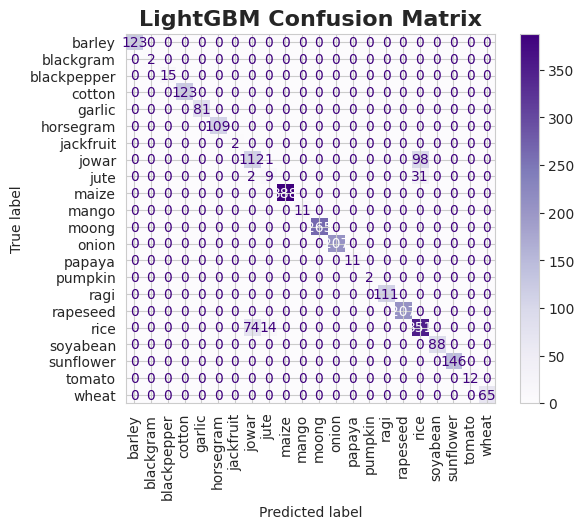

In [56]:
cm = confusion_matrix(
    y_test,
    lgbm_pred
)

plt.figure(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Purples",
    xticks_rotation=90,
    values_format="d"
)

plt.title(
    "LightGBM Confusion Matrix",
    fontsize=16,
    weight="bold"
)

plt.show()

In [60]:
with open('LightBGM.pkl', 'wb') as file:
    pickle.dump(lgbm_pred, file)

In [63]:
lgbm_results = {
    "Model":"LightGBM",
    "Accuracy":lgbm_accuracy,
    "Precision":lgbm_precision,
    "Recall":lgbm_recall,
    "F1 Score":lgbm_f1,
    "CV Accuracy":lgbm_cv.mean()
}

display(pd.DataFrame([lgbm_results]))
print("\n"+"="*80)
print("SECTION 5.3 COMPLETED SUCCESSFULLY")
print("="*80)

,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy
0,LightGBM,0.917293,0.913711,0.917293,0.914756,0.918132



SECTION 5.3 COMPLETED SUCCESSFULLY


In [64]:
print("=" * 80)
print("SECTION 6 : CROP MODEL COMPARISON")
print("=" * 80)

SECTION 6 : CROP MODEL COMPARISON


In [78]:
comparison_df = pd.DataFrame([
    rf_results,
    xgb_results,
    lgbm_results
])

comparison_df = comparison_df.round(4)

print("\nModel Performance Comparison")
print("-"*80)

display(comparison_df)

comparison_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "Model_Performance_Comparison.csv"
    ),
    index=False
)

comparison_df.to_csv("Model_Performance_Comparison.csv", index=False)
print("Comparison results saved successfully.")


Model Performance Comparison
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy
0,Random Forest,0.9120,0.9099,0.9120,0.9107,0.9130
1,XGBoost,0.9135,0.9124,0.9135,0.9129,0.9184
2,LightGBM,0.9173,0.9137,0.9173,0.9148,0.9181


Comparison results saved successfully.


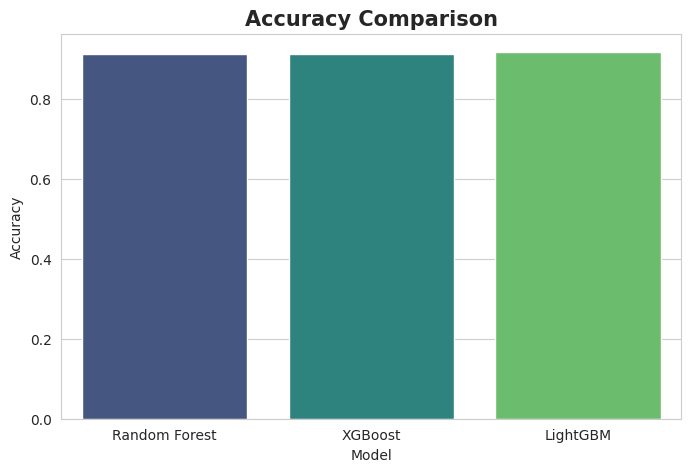

In [80]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Accuracy Comparison",
    fontsize=15,
    weight="bold"
)

plt.ylabel("Accuracy")
plt.savefig("Accuracy_Comparison.png")
plt.show()

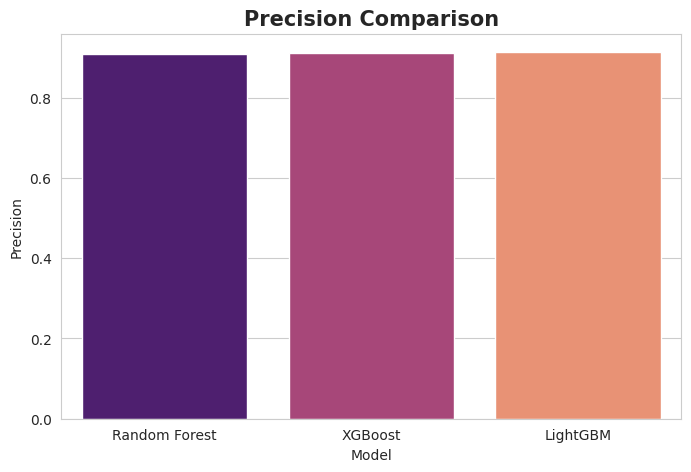

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Precision",
    palette="magma"
)

plt.title(
    "Precision Comparison",
    fontsize=15,
    weight="bold"
)

plt.savefig("Precision_Comparison.png")
plt.show()

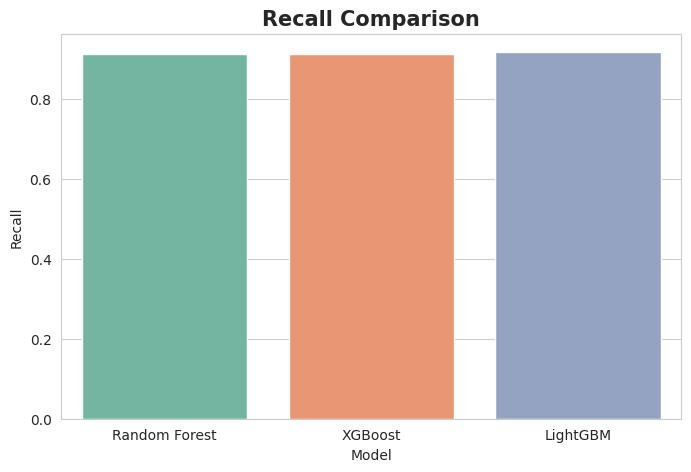

In [83]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Recall",
    palette="Set2"
)

plt.title(
    "Recall Comparison",
    fontsize=15,
    weight="bold"
)

plt.savefig("Recall_Comparison.png")
plt.show()

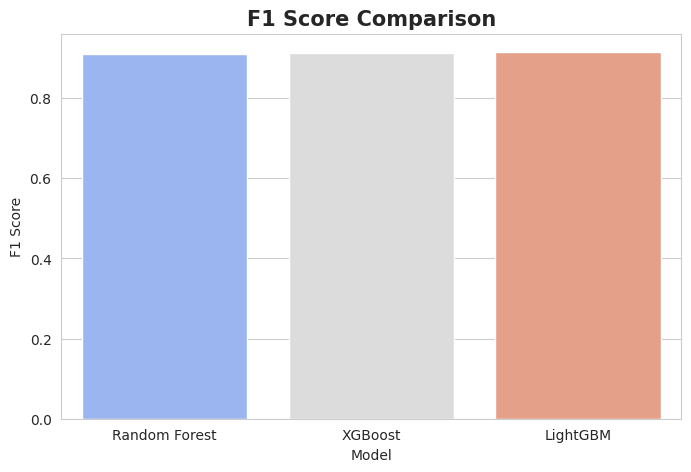

In [84]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1 Score",
    palette="coolwarm"
)

plt.title(
    "F1 Score Comparison",
    fontsize=15,
    weight="bold"
)

plt.savefig("F1_Comparison.png")
plt.show()

In [85]:
best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("\n"+"="*80)
print("BEST MODEL")
print("="*80)

print(f"Model               : {best_model['Model']}")
print(f"Accuracy            : {best_model['Accuracy']:.4f}")
print(f"Precision           : {best_model['Precision']:.4f}")
print(f"Recall              : {best_model['Recall']:.4f}")
print(f"F1 Score            : {best_model['F1 Score']:.4f}")
print(f"CV Accuracy         : {best_model['CV Accuracy']:.4f}")


BEST MODEL
Model               : LightGBM
Accuracy            : 0.9173
Precision           : 0.9137
Recall              : 0.9173
F1 Score            : 0.9148
CV Accuracy         : 0.9181


In [86]:
ranking = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

ranking.index += 1

print("\nModel Ranking")
print("-"*80)

display(ranking)


Model Ranking
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy
1,LightGBM,0.9173,0.9137,0.9173,0.9148,0.9181
2,XGBoost,0.9135,0.9124,0.9135,0.9129,0.9184
3,Random Forest,0.9120,0.9099,0.9120,0.9107,0.9130


In [87]:
joblib.dump(
    best_model["Model"],
    os.path.join(
        MODEL_DIR,
        "Best_Crop_Model.pkl"
    )
)

with open('best_model.pkl', 'wb') as file:
    pickle.dump(lgbm_pred, file)

print("\nBest Model Information Saved.")


Best Model Information Saved.


In [88]:
print("\n"+"="*80)
print("SECTION 6 COMPLETED SUCCESSFULLY")
print("="*80)


SECTION 6 COMPLETED SUCCESSFULLY


In [90]:
rf_importance = pd.DataFrame({

    "Feature": FEATURES,
    "Random Forest": best_rf.feature_importances_

})

# ============================================================
# XGBoost Feature Importance
# ============================================================

xgb_importance = pd.DataFrame({

    "Feature": FEATURES,
    "XGBoost": best_xgb.feature_importances_

})

# ============================================================
# LightGBM Feature Importance
# ============================================================

lgbm_importance = pd.DataFrame({

    "Feature": FEATURES,
    "LightGBM": best_lgbm.feature_importances_

})

In [91]:
importance_df = rf_importance.merge(
    xgb_importance,
    on="Feature"
)

importance_df = importance_df.merge(
    lgbm_importance,
    on="Feature"
)

In [92]:
importance_df["Random Forest"] = (
    importance_df["Random Forest"] /
    importance_df["Random Forest"].max()
)

importance_df["XGBoost"] = (
    importance_df["XGBoost"] /
    importance_df["XGBoost"].max()
)

importance_df["LightGBM"] = (
    importance_df["LightGBM"] /
    importance_df["LightGBM"].max()
)

In [93]:
importance_df["Average"] = (
    importance_df["Random Forest"] +
    importance_df["XGBoost"] +
    importance_df["LightGBM"]
) / 3

importance_df = importance_df.sort_values(
    by="Average",
    ascending=False
)

print("\nCombined Feature Importance\n")
display(importance_df)


Combined Feature Importance



,Feature,Random Forest,XGBoost,LightGBM,Average
0,N,1.000000,0.839791,0.260615,0.700135
2,K,0.725203,1.000000,0.247442,0.657548
5,rainfall,0.171983,0.067894,1.000000,0.413292
4,ph,0.520646,0.197481,0.483122,0.400416
1,P,0.409554,0.596919,0.140905,0.382459
3,temperature,0.120993,0.040291,0.963845,0.375043


In [101]:
print("=" * 80)
print("SECTION 8 : SHAP EXPLAINABILITY")
print("=" * 80)

SECTION 8 : SHAP EXPLAINABILITY


In [100]:
model_dict = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}

best_model_name = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(),
    "Model"
]

best_model = model_dict[best_model_name]

print(f"\nBest Model Selected : {best_model_name}")


Best Model Selected : LightGBM


In [103]:
explainer = shap.TreeExplainer(best_model)
print("\nGenerating SHAP Values...")

shap_values = explainer.shap_values(X_test)
print("SHAP Values Generated Successfully.")


Generating SHAP Values...
SHAP Values Generated Successfully.


In [107]:
print(type(shap_values))
print(X_test.shape)

if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(f"Class {i}: {sv.shape}")
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(2660, 6)
(2660, 6, 22)


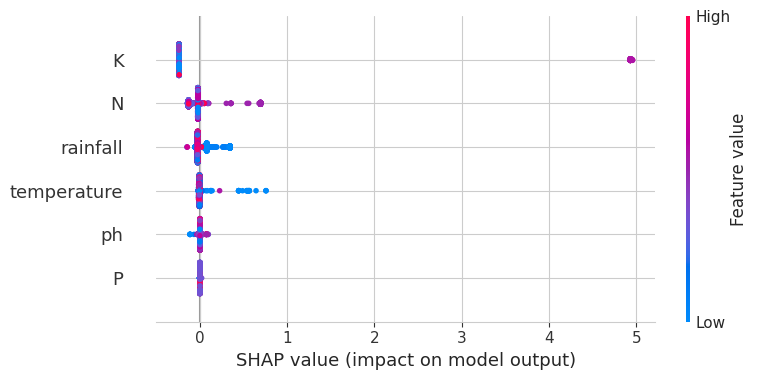

In [108]:
class_idx = 0

shap.summary_plot(
    shap_values[:, :, class_idx],
    X_test,
    feature_names=FEATURES,
    show=False
)

plt.savefig("SHAP_Summary_Class0.png", dpi=300, bbox_inches="tight")
plt.show()


Generating Waterfall Plot...


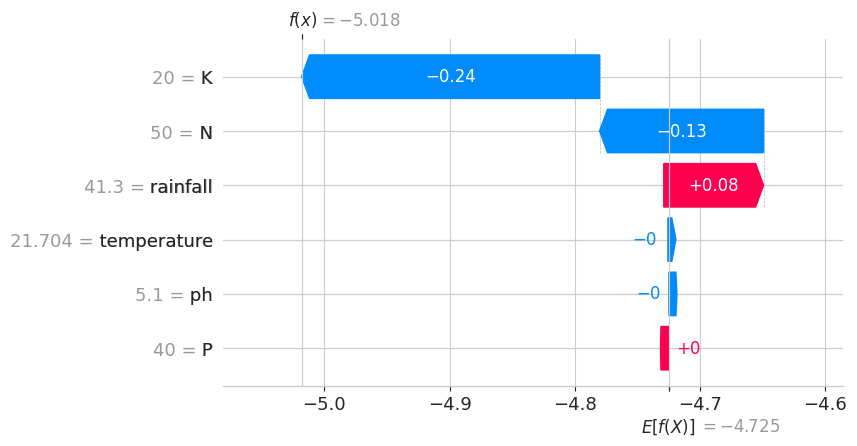

In [118]:
print("\nGenerating Waterfall Plot...")

sample_index = 0
class_idx = 0

explanation = shap.Explanation(
    values=shap_values[sample_index, :, class_idx],
    base_values=explainer.expected_value[class_idx],
    data=X_test.iloc[sample_index],
    feature_names=FEATURES
)

shap.plots.waterfall(
    explanation,
    show=False
)

plt.savefig("SHAP_Waterfall.png")

plt.show()


Generating Force Plot...


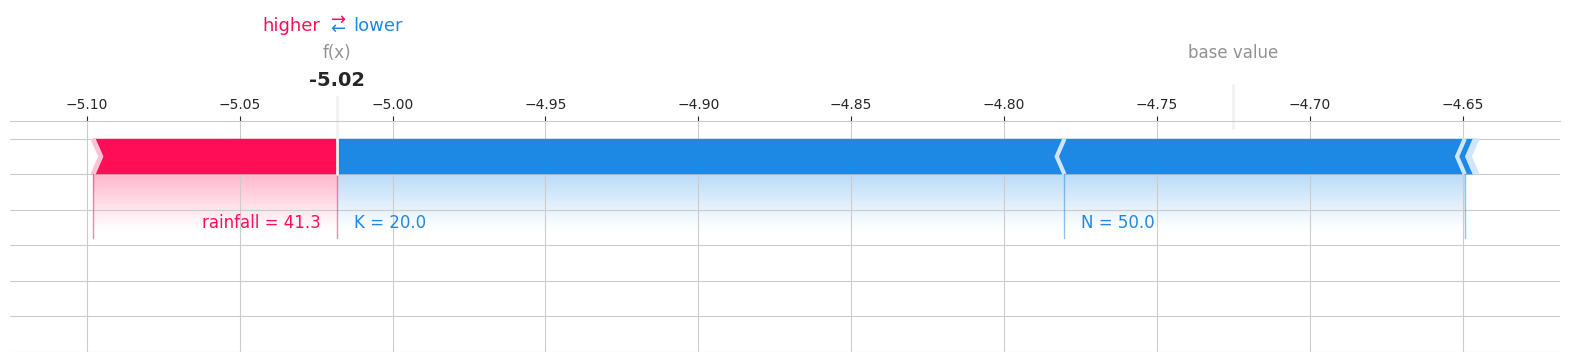

In [125]:
print("\nGenerating Force Plot...")

sample_index = 0
class_idx = 0      # Change to any class from 0 to 21

force_plot = shap.force_plot(
    explainer.expected_value[class_idx],
    shap_values[sample_index, :, class_idx],
    X_test.iloc[sample_index],
    feature_names=FEATURES,
    matplotlib=True,
    show=False
)

plt.savefig("SHAP_Force.png")

plt.show()


Generating Force Plot...


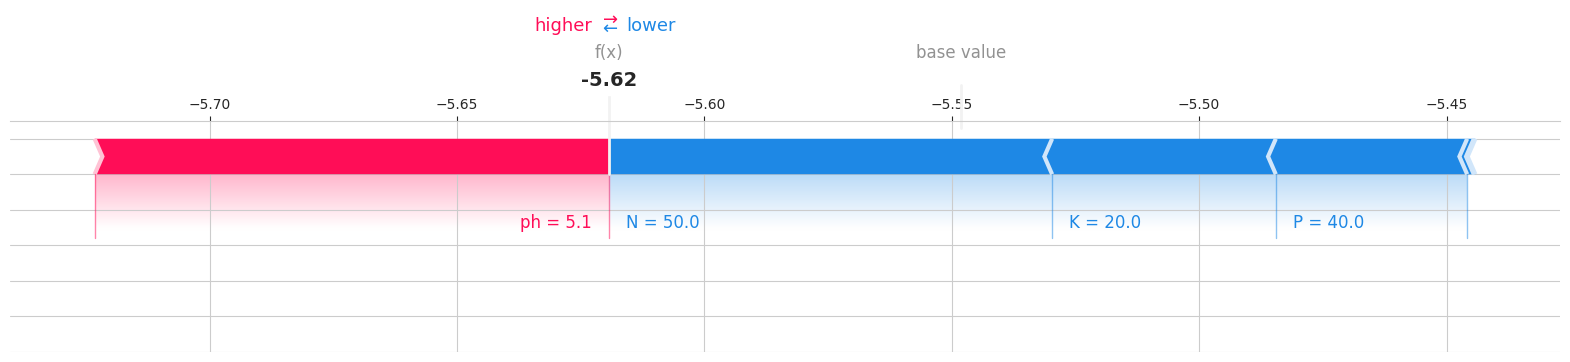

In [128]:
import numpy as np

print("\nGenerating Force Plot...")

sample_index = 0

mean_shap = np.mean(shap_values, axis=2)
mean_base = np.mean(explainer.expected_value)

force_plot = shap.force_plot(
    mean_base,
    mean_shap[sample_index],
    X_test.iloc[sample_index],
    feature_names=FEATURES,
    matplotlib=True,
    show=False
)

plt.savefig("SHAP_Force1.png")

plt.show()

In [129]:
predicted_label = best_model.predict(
    X_test.iloc[[sample_index]]
)[0]

predicted_crop = label_encoder.inverse_transform(
    [predicted_label]
)[0]

print("\n" + "=" * 80)
print("LOCAL PREDICTION EXPLANATION")
print("=" * 80)

print(f"Predicted Crop : {predicted_crop}")

print("\nInput Features")

display(
    X_test.iloc[[sample_index]]
)


LOCAL PREDICTION EXPLANATION
Predicted Crop : rapeseed

Input Features


,N,P,K,temperature,ph,rainfall
1882,50,40,20,21.704,5.1,41.3


In [133]:
mean_shap = np.mean(
    np.abs(shap_values),
    axis=(0, 2)
)

shap_df = pd.DataFrame({
    "Feature": FEATURES,
    "Mean |SHAP|": mean_shap
})

shap_df = shap_df.sort_values(
    by="Mean |SHAP|",
    ascending=False
).reset_index(drop=True)

print("\nMean SHAP Importance")

display(shap_df)

RESULT_DIR = "Results"

os.makedirs(RESULT_DIR, exist_ok=True)

shap_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "SHAP_Feature_Importance.csv"
    ),
    index=False
)

print("CSV saved successfully!")


Mean SHAP Importance


,Feature,Mean |SHAP|
0,K,0.275117
1,N,0.235412
2,P,0.134145
3,ph,0.120590
4,rainfall,0.059749
5,temperature,0.028535


CSV saved successfully!


In [134]:
print("\n" + "=" * 80)
print("SECTION 8 COMPLETED SUCCESSFULLY")
print("=" * 80)


SECTION 8 COMPLETED SUCCESSFULLY
